In [1]:
!pip install tensorflow opencv-python matplotlib numpy sympy Pillow emnist


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import cv2
from PIL import Image, ImageDraw, ImageFont
import sympy as sp
import os, warnings
warnings.filterwarnings('ignore')
print("TF version:", tf.__version__)

TF version: 2.21.0


In [4]:
import pandas as pd

print("Loading EMNIST digits from CSV...")
train_df = pd.read_csv(r"C:\Users\thota\Downloads\archive (1)\emnist-digits-train.csv", header=None)
test_df  = pd.read_csv(r"C:\Users\thota\Downloads\archive (1)\emnist-digits-test.csv",  header=None)

# First column is label, rest are 784 pixels (28x28 flattened)
y_train_d = train_df.iloc[:, 0].values
x_train_d = train_df.iloc[:, 1:].values

y_test_d = test_df.iloc[:, 0].values
x_test_d = test_df.iloc[:, 1:].values

# Reshape to (samples, 28, 28) then fix EMNIST transpose
x_train_d = x_train_d.reshape(-1, 28, 28).transpose(0, 2, 1)
x_test_d  = x_test_d.reshape(-1,  28, 28).transpose(0, 2, 1)

# Normalize + add channel dim
x_train_d = x_train_d.astype("float32")[..., np.newaxis] / 255.0
x_test_d  = x_test_d.astype("float32")[..., np.newaxis]  / 255.0

print(f"Train: {x_train_d.shape} | Test: {x_test_d.shape}")

Loading EMNIST digits from CSV...
Train: (240000, 28, 28, 1) | Test: (40000, 28, 28, 1)


In [16]:
# No operator model needed — we use geometry instead
OPERATORS = ['+', '-', '*', '/', '=', 'x']

def classify_character(crop):
    """
    Strategy:
    - Try digit model first with high confidence threshold
    - If digit confidence is low, use shape heuristics for operator
    """
    inp = crop[np.newaxis, ..., np.newaxis]
    digit_probs = digit_model.predict(inp, verbose=0)[0]
    digit_conf  = np.max(digit_probs)
    digit_pred  = np.argmax(digit_probs)

    # High confidence → it's a digit
    if digit_conf > 0.85:
        return str(digit_pred), "digit", digit_conf

    # Low confidence → use shape heuristics for operator
    return detect_operator_by_shape(crop)


def detect_operator_by_shape(crop):
    """
    Geometric heuristics for math operators.
    crop is a 28x28 float32 array (white symbol on black bg).
    """
    binary = (crop > 0.3).astype(np.uint8) * 255

    # --- Basic stats ---
    rows = np.any(binary, axis=1)   # which rows have ink
    cols = np.any(binary, axis=0)   # which cols have ink
    row_indices = np.where(rows)[0]
    col_indices = np.where(cols)[0]

    if len(row_indices) == 0:
        return '?', "heuristic", 0.0

    h_span = row_indices[-1] - row_indices[0] + 1   # vertical ink height
    w_span = col_indices[-1] - col_indices[0] + 1   # horizontal ink width
    aspect = w_span / (h_span + 1e-5)

    # Ink in top half vs bottom half
    mid = binary.shape[0] // 2
    top_ink    = np.sum(binary[:mid])
    bottom_ink = np.sum(binary[mid:])
    mid_ink    = np.sum(binary[10:18, :])   # middle horizontal band
    total_ink  = np.sum(binary)

    # Count horizontal runs in middle band (helps detect = vs -)
    mid_row  = binary[13:15, :]
    mid_runs = np.sum(np.diff(mid_row[0]) > 0)   # rising edges = strokes

    # --- Decision rules ---

    # '=' : two horizontal bars → ink in both top and bottom bands
    top_band    = np.sum(binary[6:12,  :])
    bottom_band = np.sum(binary[16:22, :])
    if top_band > 300 and bottom_band > 300 and h_span < 16:
        return '=', "heuristic", 0.90

    # '-' : single wide horizontal bar, small height
    if aspect > 2.0 and h_span < 10:
        return '-', "heuristic", 0.85

    # '+' : both wide and tall with ink in center
    center_h = np.sum(binary[10:18, :])
    center_v = np.sum(binary[:, 10:18])
    if center_h > 200 and center_v > 200 and aspect < 2.0:
        return '+', "heuristic", 0.85

    # '/' : diagonal — ink spreads from bottom-left to top-right
    top_right    = np.sum(binary[:14,  14:])
    bottom_left  = np.sum(binary[14:, :14])
    if top_right > 150 and bottom_left > 150 and aspect < 1.5:
        return '/', "heuristic", 0.80

    # 'x' or '*' (multiplication) : two crossing diagonals
    top_left     = np.sum(binary[:14, :14])
    top_right2   = np.sum(binary[:14, 14:])
    bottom_left2 = np.sum(binary[14:, :14])
    bottom_right = np.sum(binary[14:, 14:])
    quadrants    = [top_left, top_right2, bottom_left2, bottom_right]
    if all(q > 100 for q in quadrants):
        return 'x', "heuristic", 0.80

    # Fallback
    return '?', "heuristic", 0.0

In [7]:
print("=" * 40)
print("Training DIGIT model...")
print("=" * 40)

digit_history = digit_model.fit(
    x_train_d, y_train_d,
    epochs=8,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

d_loss, d_acc = digit_model.evaluate(x_test_d, y_test_d, verbose=0)
print(f"\n✅ Digit Test Accuracy: {d_acc:.2%}")

print("\n" + "=" * 40)
print("Training OPERATOR model...")
print("=" * 40)

op_history = op_model.fit(
    x_train_op, y_train_op,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

o_loss, o_acc = op_model.evaluate(x_test_op, y_test_op, verbose=0)
print(f"\n✅ Operator Test Accuracy: {o_acc:.2%}")

Training DIGIT model...
Epoch 1/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 166s 97ms/step - accuracy: 0.9799 - loss: 0.0741 - val_accuracy: 0.9895 - val_loss: 0.0383
Epoch 2/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 209s 124ms/step - accuracy: 0.9910 - loss: 0.0351 - val_accuracy: 0.9922 - val_loss: 0.0330
Epoch 3/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 202s 120ms/step - accuracy: 0.9927 - loss: 0.0273 - val_accuracy: 0.9938 - val_loss: 0.0265
Epoch 4/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 171s 101ms/step - accuracy: 0.9944 - loss: 0.0224 - val_accuracy: 0.9922 - val_loss: 0.0319
Epoch 5/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 175s 104ms/step - accuracy: 0.9952 - loss: 0.0180 - val_accuracy: 0.9912 - val_loss: 0.0355
Epoch 6/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 161s 95ms/step - accuracy: 0.9956 - loss: 0.0162 - val_accuracy: 0.9948 - val_loss: 0.0225
Epoch 7/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 159s 94ms/step - accuracy: 0.9961 - loss: 0.0143 - val_accuracy: 0.9943 - val_loss: 0.0268
Epoch 8/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 169s 10

In [8]:
digit_model.save("digit_model.keras")
op_model.save("operator_model.keras")
print("Models saved!")

Models saved!


In [10]:
def segment_characters(image_path, debug=False):
    """
    Returns list of (crop_28x28, bbox) sorted left-to-right.
    Works for dark ink on white paper (or inverted automatically).
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load: {image_path}")

    # Auto-invert: EMNIST style = white digit on black bg
    if np.mean(img) > 127:
        img = cv2.bitwise_not(img)

    # Denoise + threshold
    img = cv2.GaussianBlur(img, (3,3), 0)
    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Dilate slightly to connect broken strokes (helps multi-digit numbers)
    kernel = np.ones((2,2), np.uint8)
    dilated = cv2.dilate(thresh, kernel, iterations=1)

    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bboxes = [cv2.boundingRect(c) for c in contours]
    # Filter noise (very small blobs)
    bboxes = [b for b in bboxes if b[2]*b[3] > 40]
    # Sort left → right
    bboxes = sorted(bboxes, key=lambda b: b[0])

    crops = []
    for (x, y, w, h) in bboxes:
        crop = thresh[y:y+h, x:x+w]
        # Pad to square then resize to 28x28
        size = max(w, h)
        padded = np.zeros((size, size), dtype=np.uint8)
        x_off = (size - w) // 2
        y_off = (size - h) // 2
        padded[y_off:y_off+h, x_off:x_off+w] = crop
        resized = cv2.resize(padded, (28,28)).astype("float32") / 255.0
        crops.append(resized)

    if debug:
        fig, axes = plt.subplots(1, len(crops)+1, figsize=(2*(len(crops)+1), 2))
        color_img = cv2.cvtColor(cv2.bitwise_not(thresh), cv2.COLOR_GRAY2BGR)
        for (x,y,w,h) in bboxes:
            cv2.rectangle(color_img, (x,y), (x+w,y+h), (0,200,0), 2)
        axes[0].imshow(cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Segments"); axes[0].axis('off')
        for i, crop in enumerate(crops):
            axes[i+1].imshow(crop, cmap='gray')
            axes[i+1].set_title(f"#{i}"); axes[i+1].axis('off')
        plt.tight_layout(); plt.show()

    return crops, bboxes

In [17]:
DIGIT_CHARS = [str(i) for i in range(10)]

def classify_character(crop):
    """
    Run both models, pick whichever is more confident.
    Returns (character_string, model_used)
    """
    inp = crop[np.newaxis, ..., np.newaxis]

    digit_probs = digit_model.predict(inp, verbose=0)[0]
    op_probs    = op_model.predict(inp,    verbose=0)[0]

    digit_conf = np.max(digit_probs)
    op_conf    = np.max(op_probs)

    if digit_conf >= op_conf:
        return DIGIT_CHARS[np.argmax(digit_probs)], "digit", digit_conf
    else:
        return OPERATORS[np.argmax(op_probs)], "operator", op_conf


def predict_equation(image_path, debug=False):
    crops, bboxes = segment_characters(image_path, debug=debug)

    equation_parts = []
    print(f"\n{'#':<5} {'Predicted':<12} {'Method':<12} {'Confidence'}")
    print("-" * 45)

    for i, crop in enumerate(crops):
        char, method, conf = classify_character(crop)
        equation_parts.append(char)
        print(f"#{i:<4} {char:<12} {method:<12} {conf:.2%}")

    equation_str = ''.join(equation_parts)
    print(f"\n📝 Raw prediction: {equation_str}")
    return equation_str

In [18]:
def solve(eq_str):
    # Normalize
    eq_str = (eq_str
              .replace('×', '*')
              .replace('÷', '/')
              .replace('X', 'x'))

    # If 'x' appears next to digits with no operator, insert *
    # e.g. "3x4" → "3*4", "2x+3=7" → "2*x+3=7"
    import re
    # digit followed by x (variable?) — decide based on = sign
    has_equals = '=' in eq_str

    if not has_equals:
        # x is multiplication operator: 3x4 → 3*4
        eq_str = re.sub(r'(\d)x(\d)', r'\1*\2', eq_str)
        eq_str = re.sub(r'(\d)x$', r'\1*x', eq_str)
    else:
        # x is variable: 2x+3=7 → 2*x+3=7
        eq_str = re.sub(r'(\d)x', r'\1*x', eq_str)

    sym_x = sp.Symbol('x')

    try:
        if '=' in eq_str:
            lhs_str, rhs_str = eq_str.split('=', 1)
            lhs = sp.sympify(lhs_str)
            rhs = sp.sympify(rhs_str)
            solutions = sp.solve(lhs - rhs, sym_x)
            return f"x = {solutions}"
        else:
            result = sp.sympify(eq_str)
            evaluated = float(result)
            return f"{eq_str} = {evaluated:.6g}"
    except Exception as e:
        return f"❌ Could not solve '{eq_str}': {e}"


def predict_and_solve(image_path, debug=True):
    print(f"\n🔍 Processing: {image_path}")
    eq = predict_equation(image_path, debug=debug)
    answer = solve(eq)
    print(f"\n✅ Answer: {answer}")
    return eq, answer

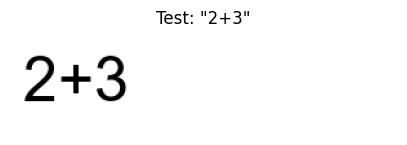


🔍 Processing: test_2+3.png


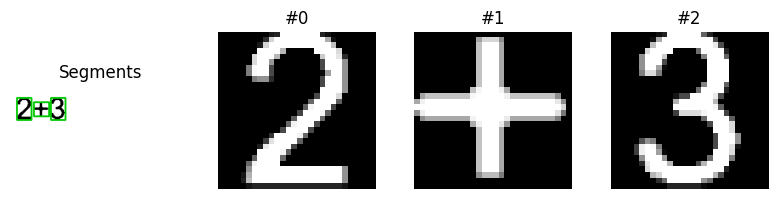


#     Predicted    Method       Confidence
---------------------------------------------
#0    2            digit        100.00%
#1    4            digit        100.00%
#2    3            digit        100.00%

📝 Raw prediction: 243

✅ Answer: 243 = 243


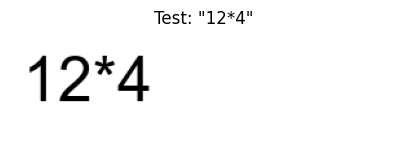


🔍 Processing: test_12mul4.png


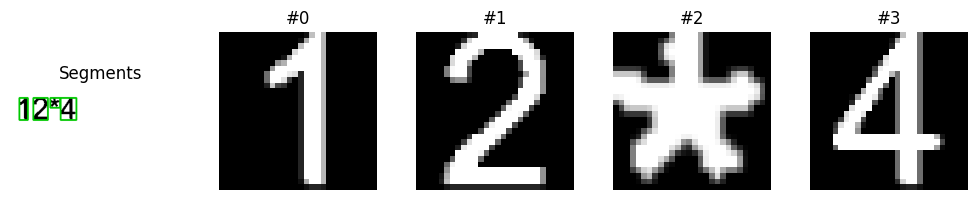


#     Predicted    Method       Confidence
---------------------------------------------
#0    *            operator     99.99%
#1    2            digit        100.00%
#2    *            operator     100.00%
#3    4            digit        100.00%

📝 Raw prediction: *2*4

✅ Answer: ❌ Could not solve '*2*4': Sympify of expression 'could not parse '*2*4'' failed, because of exception being raised:
SyntaxError: invalid syntax (<string>, line 1)


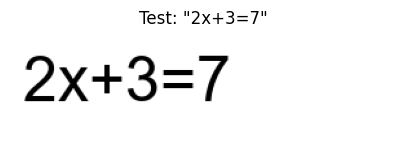


🔍 Processing: test_2x+3eq7.png


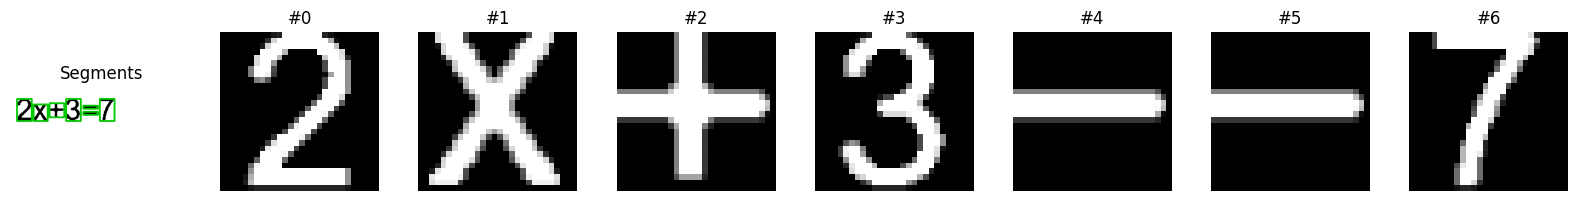


#     Predicted    Method       Confidence
---------------------------------------------
#0    2            digit        100.00%
#1    *            operator     100.00%
#2    4            digit        100.00%
#3    3            digit        100.00%
#4    =            operator     100.00%
#5    =            operator     100.00%
#6    /            operator     98.69%

📝 Raw prediction: 2*43==/

✅ Answer: ❌ Could not solve '2*43==/': Sympify of expression 'could not parse '=/'' failed, because of exception being raised:
SyntaxError: invalid syntax (<string>, line 1)


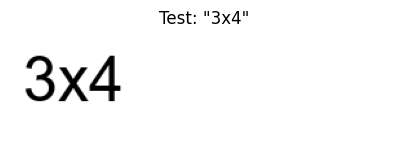


🔍 Processing: test_3x4.png


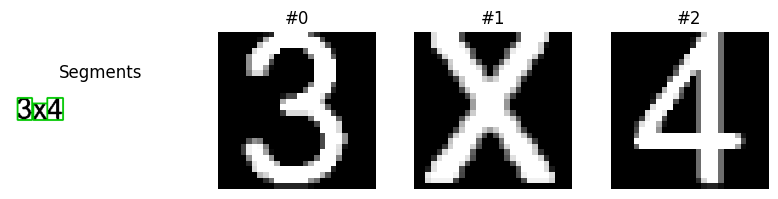


#     Predicted    Method       Confidence
---------------------------------------------
#0    3            digit        100.00%
#1    8            digit        100.00%
#2    4            digit        100.00%

📝 Raw prediction: 384

✅ Answer: 384 = 384


In [19]:
def make_test_image(equation, path="test.png"):
    """Creates a clean white-paper-style test image."""
    img = Image.new('L', (300, 80), color=255)
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype("arial.ttf", 48)
    except:
        font = ImageFont.load_default()
    draw.text((10, 10), equation, fill=0, font=font)
    img.save(path)
    plt.figure(figsize=(5,2))
    plt.imshow(np.array(img), cmap='gray')
    plt.title(f'Test: "{equation}"'); plt.axis('off'); plt.show()
    return path

# Test cases
for eq in ["2+3", "12*4", "2x+3=7", "3x4"]:
    safe = eq.replace('*','mul').replace('=','eq').replace('/','div')
    p = make_test_image(eq, f"test_{safe}.png")
    predict_and_solve(p, debug=True)


🔍 Processing: C:\Users\thota\Downloads\WhatsApp Image 2026-03-16 at 15.48.33 (1).jpeg


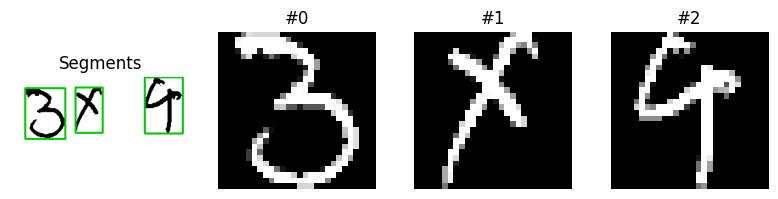


#     Predicted    Method       Confidence
---------------------------------------------
#0    /            operator     100.00%
#1    8            digit        100.00%
#2    /            operator     100.00%

📝 Raw prediction: /8/

✅ Answer: ❌ Could not solve '/8/': Sympify of expression 'could not parse '/8/'' failed, because of exception being raised:
SyntaxError: invalid syntax (<string>, line 1)


In [20]:
# Photograph your equation on white paper, transfer to Windows,
# then update the path below

MY_IMAGE = r"C:\Users\thota\Downloads\WhatsApp Image 2026-03-16 at 15.48.33 (1).jpeg"  # ← change this

eq, answer = predict_and_solve(MY_IMAGE, debug=True)